In [1]:
# BASIC STEPS

!pip install transformers
!pip install opencv-python
!pip install tensorboard
!pip install timm

import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
from torchvision import models, transforms
import time
from transformers import CLIPModel, CLIPProcessor, ViTModel, ViTFeatureExtractor
import numpy as np
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
from PIL import Image
from timm import create_model
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
import shutil
import random
from pathlib import Path




from google.colab import drive
drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 112.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit


Visualizing sample training images...


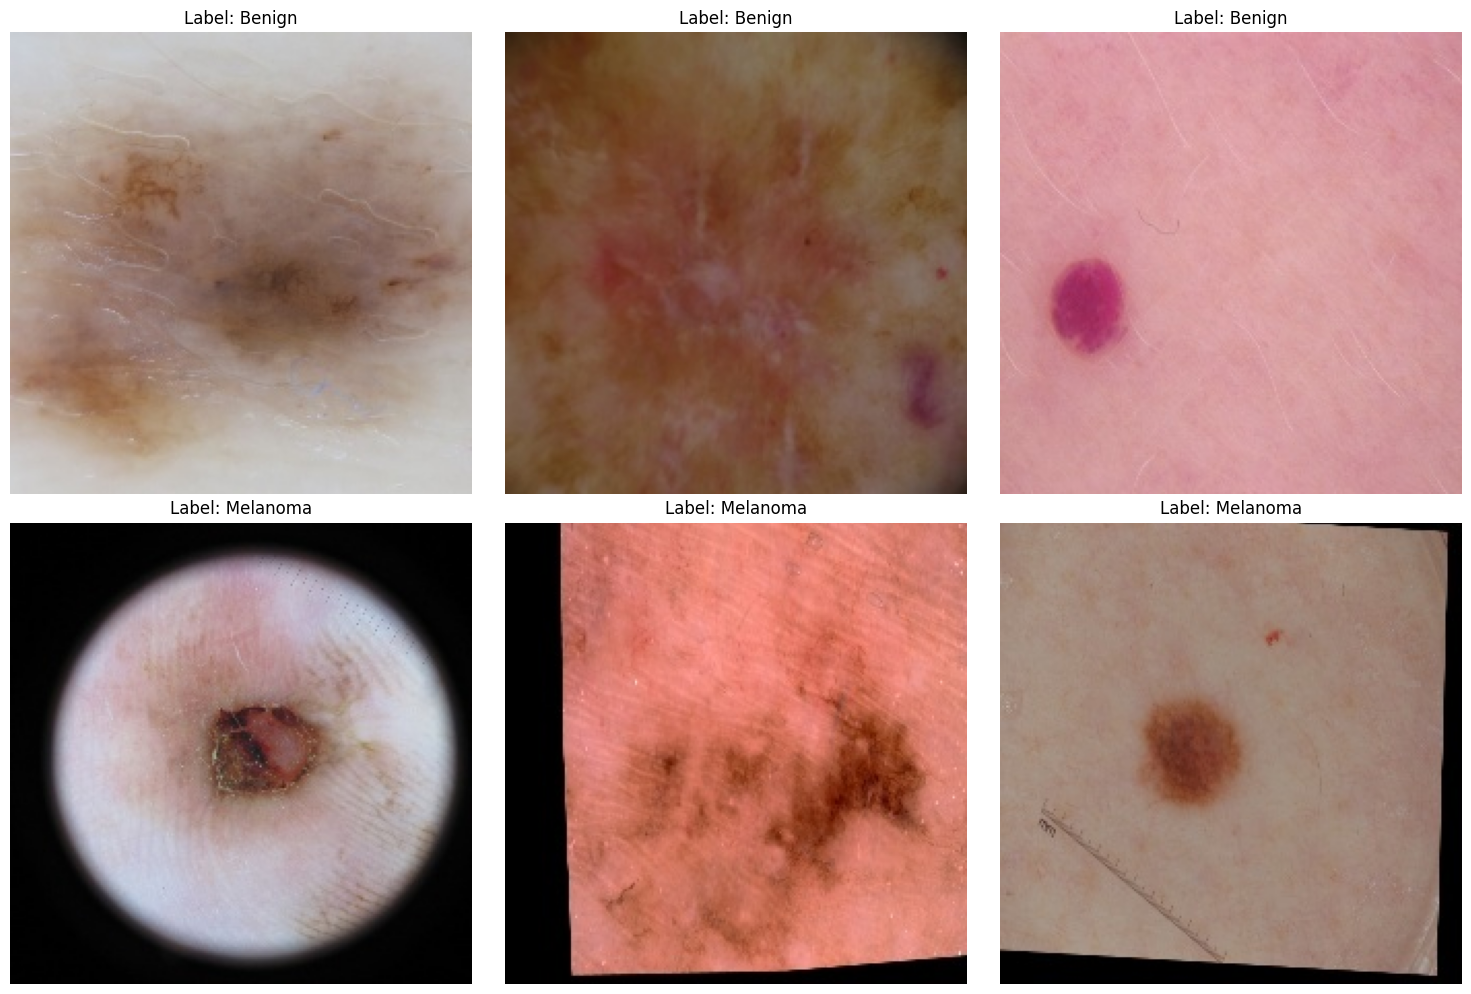

Train/Validation split complete. DataLoaders are ready.
Sample Images Shape: torch.Size([128, 3, 224, 224])
Sample Labels Shape: torch.Size([128])


In [4]:
import random
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import torch

# Paths
BASE_PATH = "/content/drive/MyDrive/THESIS/Dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "ISIC_2019_Train/ISIC_2019_Training_Input_Normalized")  # Contains both Benign and Melanoma
TEST_PATH = os.path.join(BASE_PATH, "ISIC_2019_Test/ISIC_2019_Test_Normalized")    # Same folder structure

# Helper: Gather image paths and labels
def get_image_paths_and_labels(root_dir):
    image_paths = []
    labels = []
    class_names = sorted(os.listdir(root_dir))  # e.g., ['Benign', 'Melanoma']
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}

    for cls_name in class_names:
        cls_folder = os.path.join(root_dir, cls_name)
        for fname in os.listdir(cls_folder):
            if fname.endswith(('.jpg', '.png')):
                img_path = os.path.join(cls_folder, fname)
                image_paths.append(img_path)
                labels.append(class_to_idx[cls_name])
    return image_paths, labels

# Visualize random training samples
def visualize_samples_from_folder(base_path, num_samples=6):
    samples = []
    for label in ["Benign", "Melanoma"]:
        class_dir = os.path.join(base_path, label)
        all_files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) if f.endswith(('.jpg', '.png'))]
        samples.extend(random.sample(all_files, min(len(all_files), num_samples // 2)))

    plt.figure(figsize=(15, 10))
    for idx, img_path in enumerate(samples):
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        label = os.path.basename(os.path.dirname(img_path))

        plt.subplot(2, 3, idx + 1)
        plt.imshow(image)
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\nVisualizing sample training images...")
visualize_samples_from_folder(TRAIN_PATH)

# Custom dataset
class ISICDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        max_attempts = 10
        attempt = 0
        while attempt < max_attempts:
            img_path = self.image_paths[idx]
            image = cv2.imread(img_path)
            if image is not None:
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                if self.transform:
                    image = self.transform(image)
                label = self.labels[idx]
                return image, label
            else:
                print(f"Unreadable image skipped at runtime: {img_path}")
                idx = (idx + 1) % len(self.image_paths)
                attempt += 1
        raise RuntimeError("Too many unreadable images in a row.")

# Load all train images and split into train/val
all_image_paths, all_labels = get_image_paths_and_labels(TRAIN_PATH)
train_image_paths, val_image_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.15, stratify=all_labels, random_state=42
)

# Load test data
test_image_paths, test_labels = get_image_paths_and_labels(TEST_PATH)

# Define transforms
data_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = ISICDataset(train_image_paths, train_labels, transform=data_transforms)
val_dataset = ISICDataset(val_image_paths, val_labels, transform=data_transforms)
test_dataset = ISICDataset(test_image_paths, test_labels, transform=data_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=12, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=12, pin_memory=True)

print("Train/Validation split complete. DataLoaders are ready.")

# Sanity check
sample_images, sample_labels = next(iter(train_loader))
print(f"Sample Images Shape: {sample_images.shape}")
print(f"Sample Labels Shape: {sample_labels.shape}")



In [5]:
# LETS GO BERSERK!
# Only on ISIC2019!
class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone va Extract features from the penultimate layer
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # It removes classifier (keeps features)

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers to prevent them from training
        for param in self.resnet_feat.parameters():
            param.requires_grad = False

        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False

        for param in self.densenet_feat.parameters():
            param.requires_grad = False

        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate the total input size dynamically for the fully connected layer
        fc_input_size = 0

        # Function to calculate the feature size from a model
        def calculate_fc_input_size(model, dummy_input):
            with torch.no_grad():
                output = model(dummy_input)
                # If the model output is a list, get the first tensor
                if isinstance(output, list):
                    output = output[0]
                output = self.global_pool(output)
                output = torch.flatten(output, 1)
                return output.shape[1]

        # Create a dummy input to calculate the feature sizes
        dummy_input = torch.randn(1, 3, 224, 224)  # Create a dummy input

        # Calculate the input size for each backbone
        fc_input_size += calculate_fc_input_size(self.resnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.efficientnet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.densenet_feat, dummy_input)
        fc_input_size += calculate_fc_input_size(self.swin_feat, dummy_input)

        # Calculate the total input size for the fully connected layer
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        # Extract features from ResNet
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        # Extract features from EfficientNet
        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        # Extract features from DenseNet
        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        # Extract features from Swin Transformer
        swin_feats = self.swin_feat(x)[-1]        # Get last feature map
        swin_out = self.global_pool(swin_feats)   # (B, C, 1, 1)
        swin_out = torch.flatten(swin_out, 1)     # Now (B, C)

        # Concatenate all features
        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        # Classification head
        out = self.fc(combined_features)
        return out


NUM_CLASSES = 2

# Only one checkpoint path for best model
best_checkpoint_dir = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized"
os.makedirs(best_checkpoint_dir, exist_ok=True)
best_checkpoint_path = os.path.join(best_checkpoint_dir, "2nd_only_2019.pth")

model = Berserker(num_classes=NUM_CLASSES)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Optimizer & Loss
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

start_epoch = 0

# No loading from previous checkpoint — start fresh every time.

def train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, patience=3):
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(start_epoch, num_epochs):
        print("Running epoch:", epoch + 1)  # Debug print
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch_idx, (inputs, labels) in enumerate(train_loader):
            print(f"Batch {batch_idx+1}/{len(train_loader)}")  # Debug print
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()


        train_acc = 100 * correct / total
        train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_loss_avg = val_loss / len(val_loader)

        print(f"[Epoch {epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss_avg:.4f} | Val Acc: {val_acc:.2f}%")

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            epochs_no_improve = 0
            print(f"Validation loss improved. Saving best checkpoint to {best_checkpoint_path}")
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict()
            }, best_checkpoint_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping after {epoch+1} epochs due to no improvement.")
                break

# Launch training
train(model, train_loader, val_loader, optimizer, criterion, num_epochs=10, patience=3)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 196MB/s]


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Running epoch: 1
Batch 1/277
Batch 2/277
Batch 3/277
Batch 4/277
Batch 5/277
Batch 6/277
Batch 7/277
Batch 8/277
Batch 9/277
Batch 10/277
Batch 11/277
Batch 12/277
Batch 13/277
Batch 14/277
Batch 15/277
Batch 16/277
Batch 17/277
Batch 18/277
Batch 19/277
Batch 20/277
Batch 21/277
Batch 22/277
Batch 23/277
Batch 24/277
Batch 25/277
Batch 26/277
Batch 27/277
Batch 28/277
Batch 29/277
Batch 30/277
Batch 31/277
Batch 32/277
Batch 33/277
Batch 34/277
Batch 35/277
Batch 36/277
Batch 37/277
Batch 38/277
Batch 39/277
Batch 40/277
Batch 41/277
Batch 42/277
Batch 43/277
Batch 44/277
Batch 45/277
Batch 46/277
Batch 47/277
Batch 48/277
Batch 49/277
Batch 50/277
Batch 51/277
Batch 52/277
Batch 53/277
Batch 54/277
Batch 55/277
Batch 56/277
Batch 57/277
Batch 58/277
Batch 59/277
Batch 60/277
Batch 61/277
Batch 62/277
Batch 63/277
Batch 64/277
Batch 65/277
Batch 66/277
Batch 67/277
Batch 68/277
Batch 69/277
Batch 70/277
Batch 71/277
Batch 72/277
Batch 73/277
Batch 74/277
Batch 75/277
Batch 76/277
Batc

Testing: 100%|██████████| 52/52 [01:32<00:00,  1.77s/it]



Test Accuracy: 0.8596
Precision: 0.5562
Recall (Sensitivity): 0.6017
F1 Score: 0.5781

Classification Report:
              precision    recall  f1-score   support

       Other       0.92      0.91      0.92      5528
    Melanoma       0.56      0.60      0.58      1052

    accuracy                           0.86      6580
   macro avg       0.74      0.76      0.75      6580
weighted avg       0.86      0.86      0.86      6580


Confusion Matrix:
[[5023  505]
 [ 419  633]]


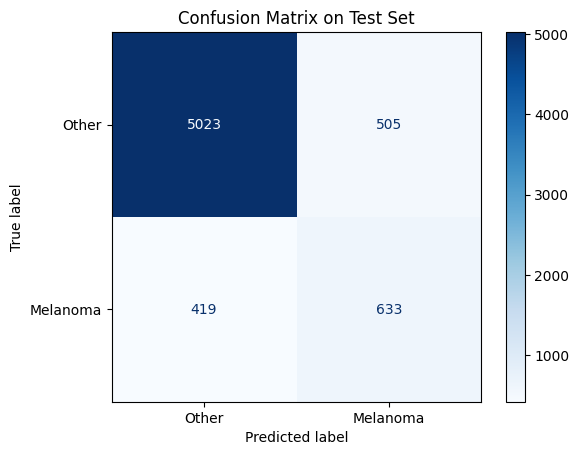

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
from torchvision import models
from timm import create_model
import numpy as np

class Berserker(nn.Module):
    def __init__(self, num_classes):
        super(Berserker, self).__init__()

        # ResNet50 Backbone
        resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet_feat = nn.Sequential(*list(resnet.children())[:-2])

        # EfficientNetB4 Backbone
        efficientnet = create_model('efficientnet_b4', pretrained=True)
        self.efficientnet_feat = nn.Sequential(*list(efficientnet.children())[:-2])  # remove classifier, keep features

        # DenseNet201 Backbone
        densenet = models.densenet201(weights="IMAGENET1K_V1")
        self.densenet_feat = densenet.features

        # Swin Transformer Backbone
        swin = create_model('swin_base_patch4_window7_224', pretrained=True, features_only=True)
        self.swin_feat = swin

        # Freeze backbone layers
        for param in self.resnet_feat.parameters():
            param.requires_grad = False
        for param in self.efficientnet_feat.parameters():
            param.requires_grad = False
        for param in self.densenet_feat.parameters():
            param.requires_grad = False
        for param in self.swin_feat.parameters():
            param.requires_grad = False

        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Calculate total input size dynamically if needed
        # (your static value is fine if confirmed)
        fc_input_size = 2048 + 1792 + 1920 + 7

        # Classification Head
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        resnet_out = self.resnet_feat(x)
        resnet_out = self.global_pool(resnet_out)
        resnet_out = torch.flatten(resnet_out, 1)

        efficientnet_out = self.efficientnet_feat(x)
        efficientnet_out = self.global_pool(efficientnet_out)
        efficientnet_out = torch.flatten(efficientnet_out, 1)

        densenet_out = self.densenet_feat(x)
        densenet_out = self.global_pool(densenet_out)
        densenet_out = torch.flatten(densenet_out, 1)

        swin_feats = self.swin_feat(x)[-1]
        swin_out = self.global_pool(swin_feats)
        swin_out = torch.flatten(swin_out, 1)

        combined_features = torch.cat(
            (resnet_out, efficientnet_out, densenet_out, swin_out), dim=1
        )

        out = self.fc(combined_features)
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Berserker(num_classes=2)
model.to(device)

best_checkpoint_path = "/content/drive/MyDrive/THESIS/Dataset/ISIC_2019_Train/ISIC_2019_Training_Input_Normalized/2nd_only_2019.pth"
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # melanoma prob (class 1)
        preds = (probs > 0.47).long()  # current threshold 0.9, change if needed

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())  # **NEW: save raw probs**

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

average_type = 'binary' if model.fc[-1].out_features == 2 else 'weighted'

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average=average_type, zero_division=0)
recall = recall_score(all_labels, all_preds, average=average_type, zero_division=0)
f1 = f1_score(all_labels, all_preds, average=average_type, zero_division=0)
cm = confusion_matrix(all_labels, all_preds)

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=["Other", "Melanoma"]))
print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Other", "Melanoma"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.savefig("confusion_matrix_test.png")
plt.show()


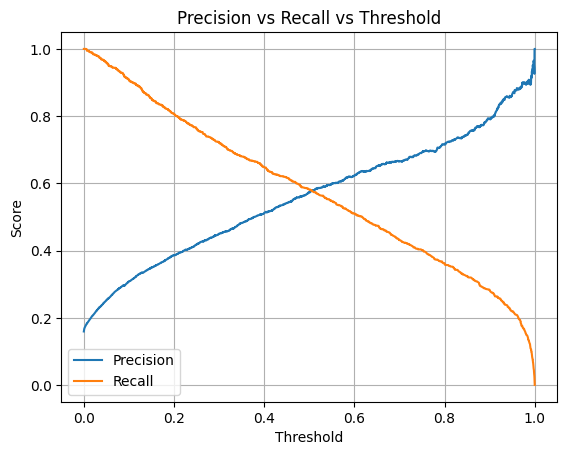

Best F1 score: 0.5795 at threshold 0.47


In [17]:
from sklearn.metrics import precision_recall_curve
from numpy import argmax


precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()



f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx = argmax(f1_scores)
print(f"Best F1 score: {f1_scores[best_idx]:.4f} at threshold {thresholds[best_idx]:.2f}")
